In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, MinMaxScaler,
                                   RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
from scipy.ndimage           import gaussian_filter1d
from scipy.stats             import zscore

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Get indices of outliers
    outlier_indices = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index
    return outlier_indices

In [ ]:
df = pd.read_csv('car_price.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [ ]:
df.isnull().sum()

,0
model,3621
year,3622
price,3621
transmission,3623
mileage,3622
fuelType,3622
tax,3621
mpg,3621
engineSize,3622
Make,3621


In [ ]:
df[df.isnull().any(axis=1)].shape

(29110, 10)

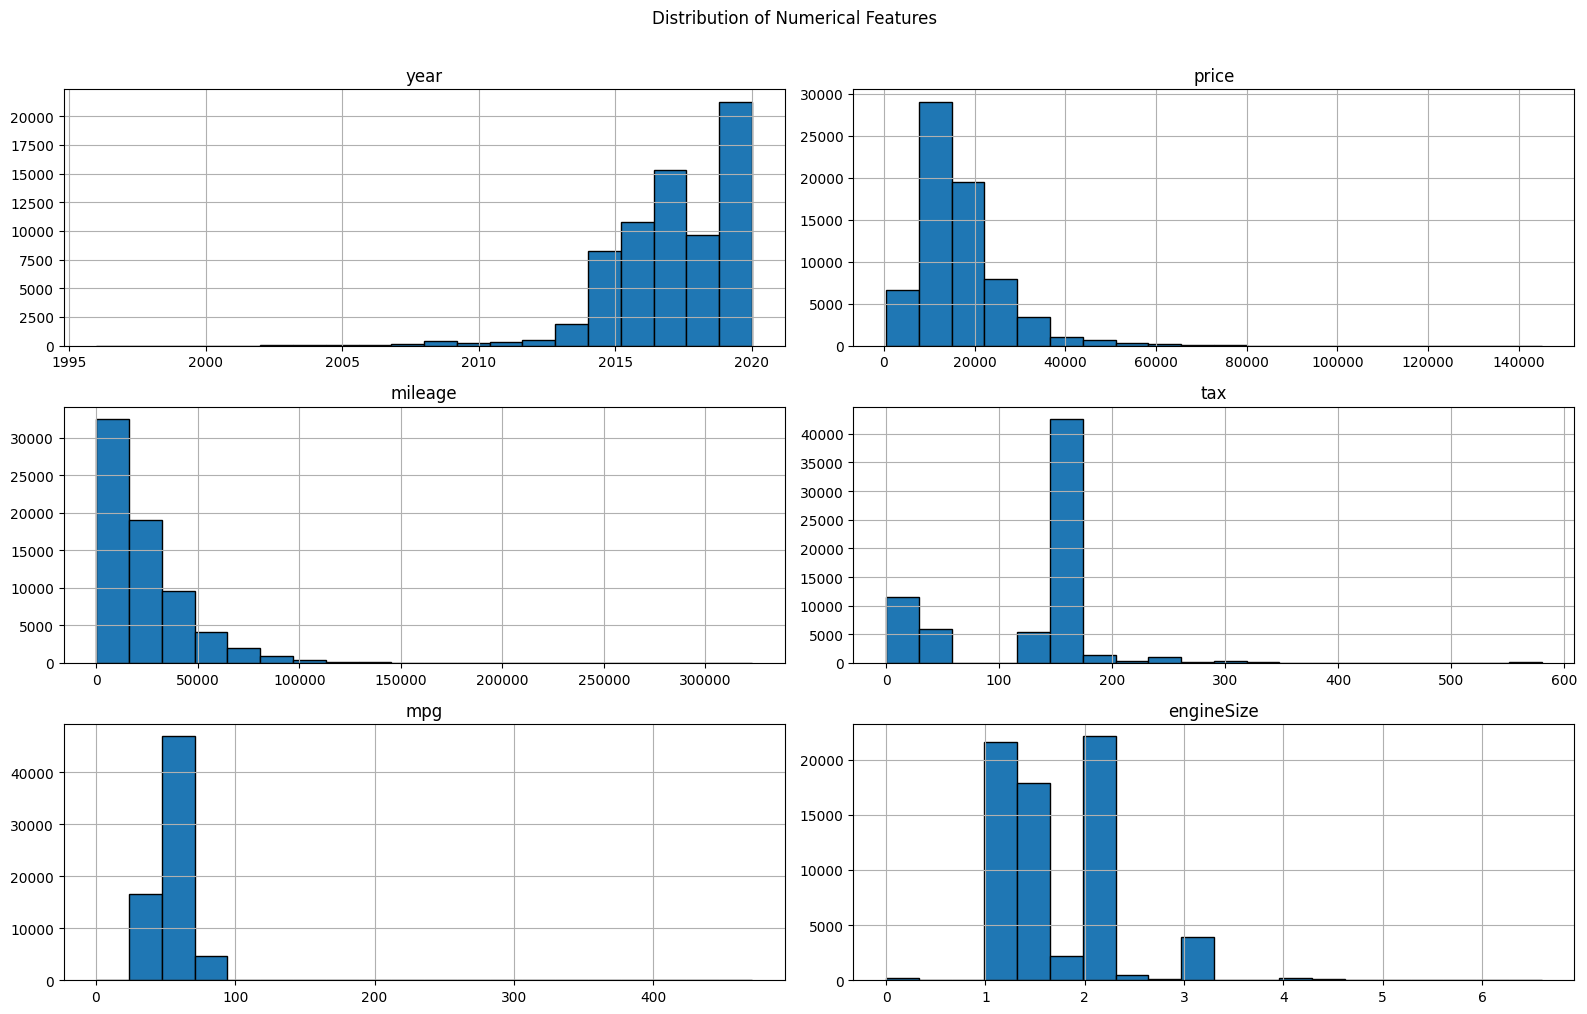

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

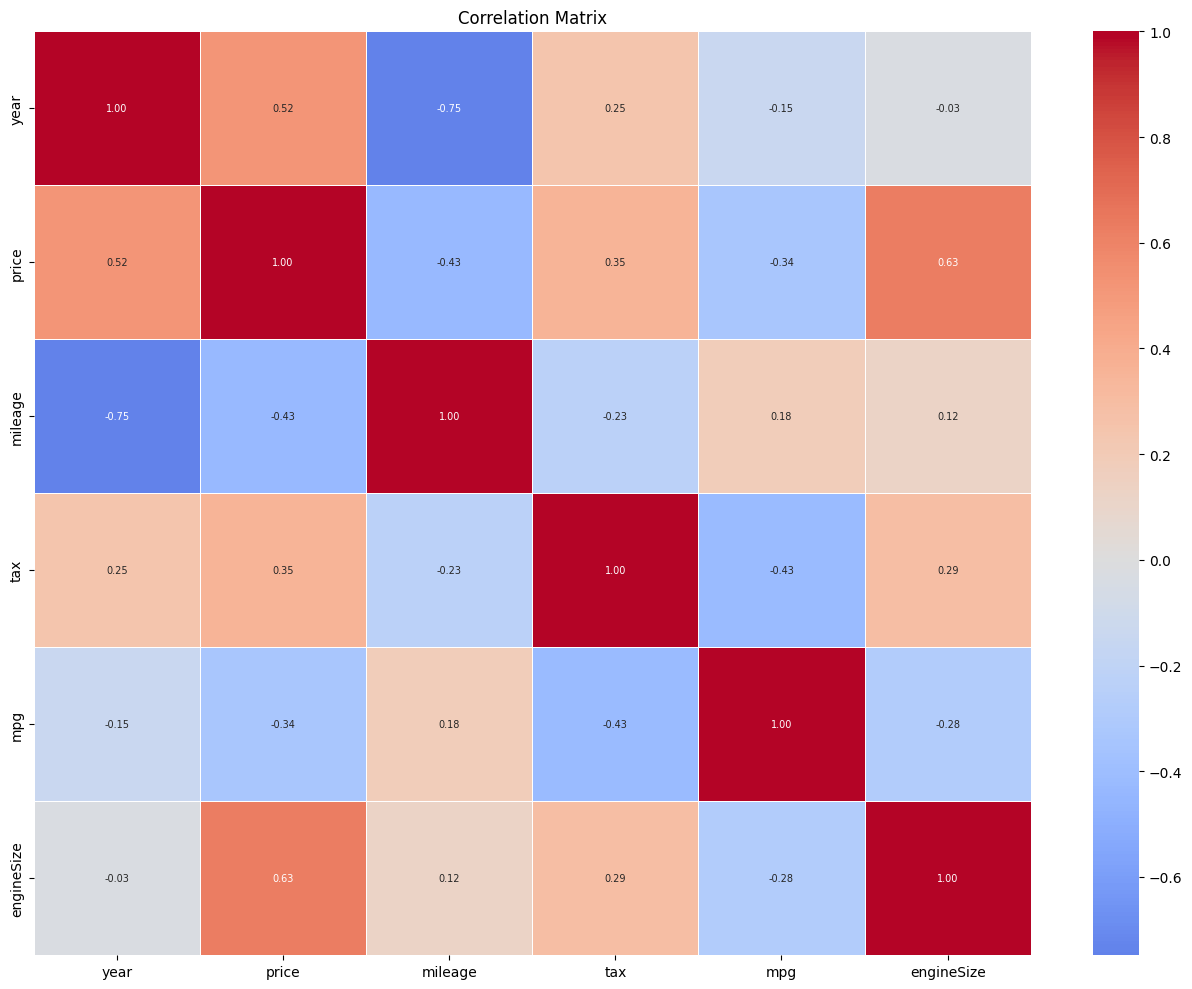

In [ ]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['model', 'transmission', 'fuelType', 'Make'], dtype='object')


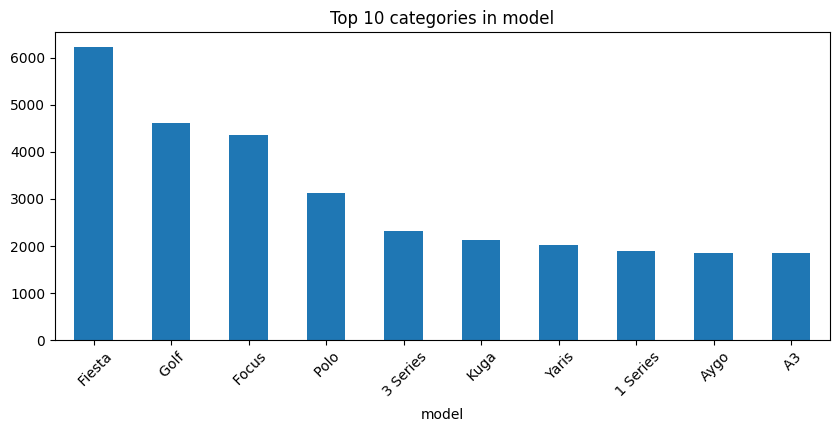

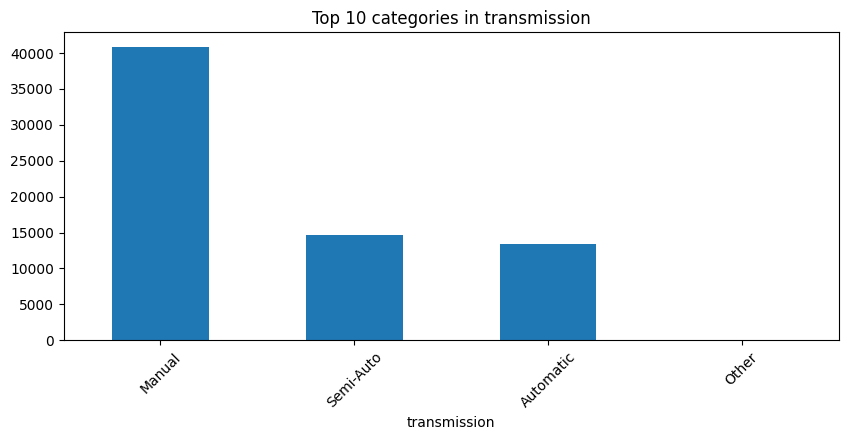

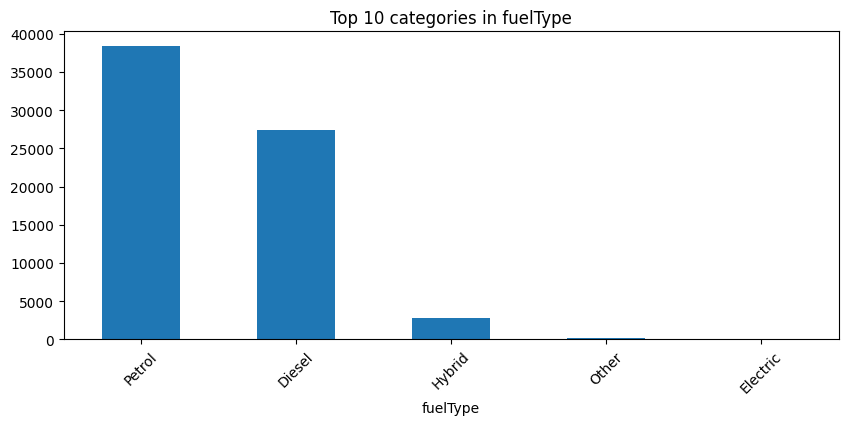

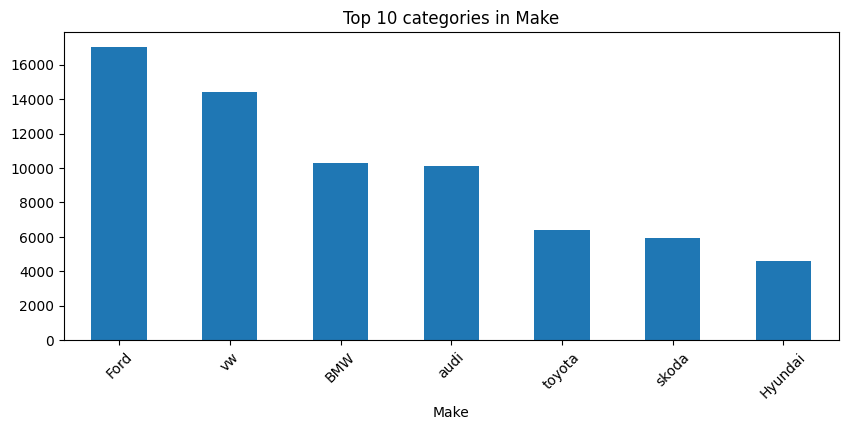

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().nlargest(10).plot(kind='bar')
    plt.title(f"Top 10 categories in {col}")
    plt.xticks(rotation=45)
    plt.show()

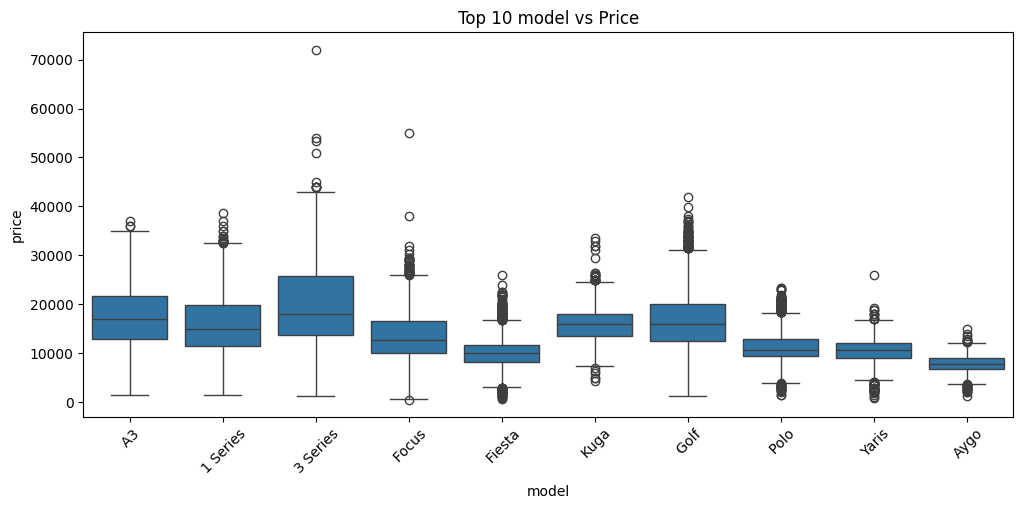

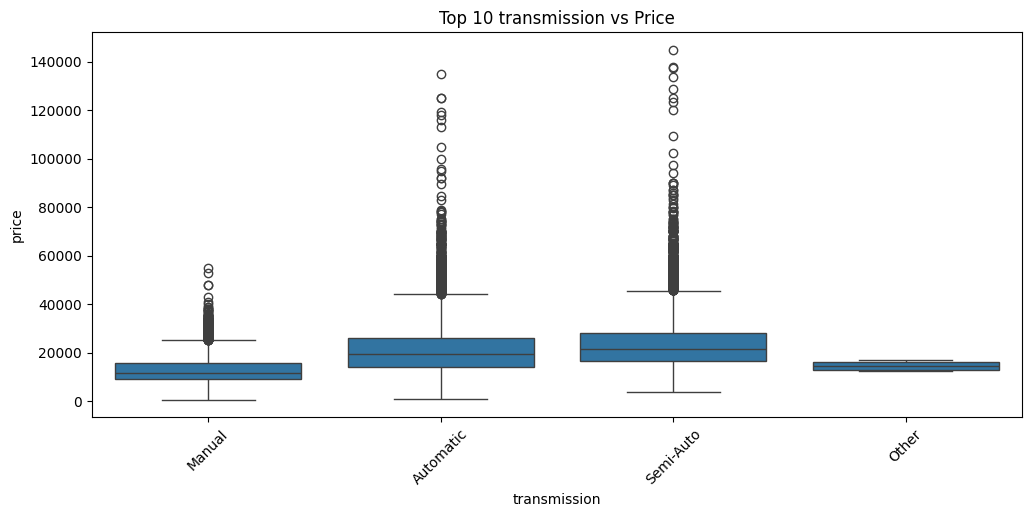

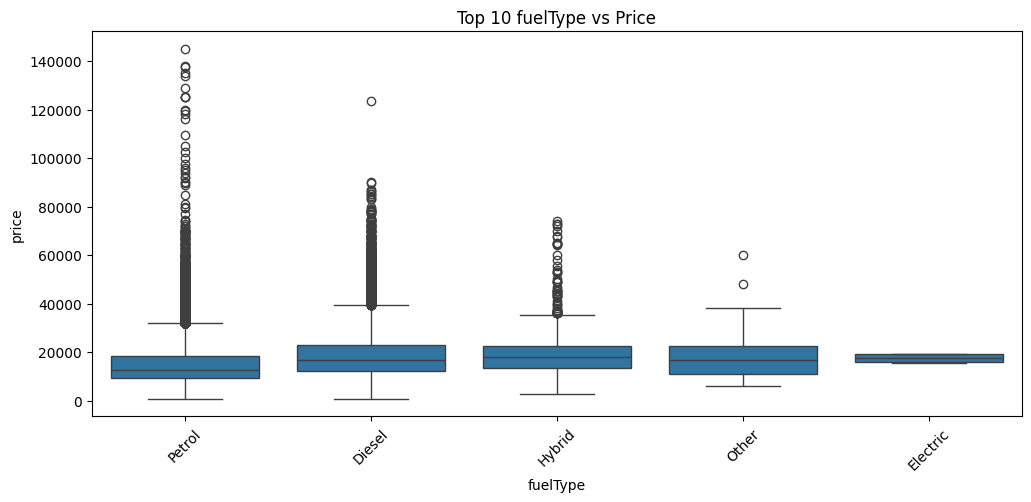

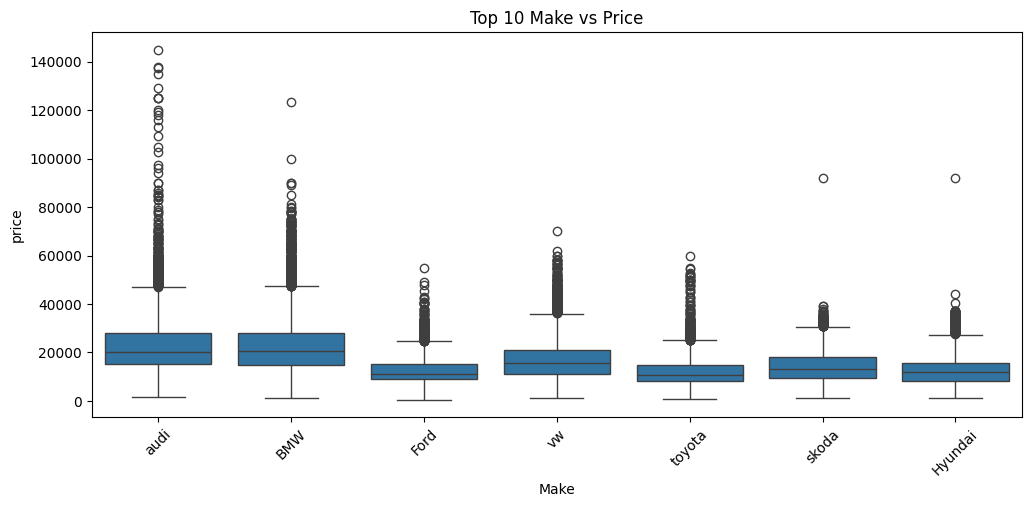

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    top10 = df[col].value_counts().nlargest(10).index
    filtered_df = df[df[col].isin(top10)]

    plt.figure(figsize=(12,5))
    sns.boxplot(data=filtered_df, x=col, y='price')
    plt.title(f"Top 10 {col} vs Price")
    plt.xticks(rotation=45)
    plt.show()

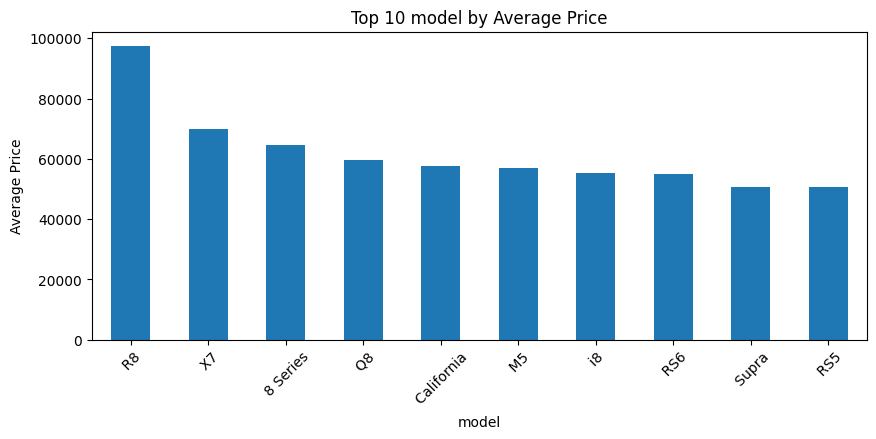

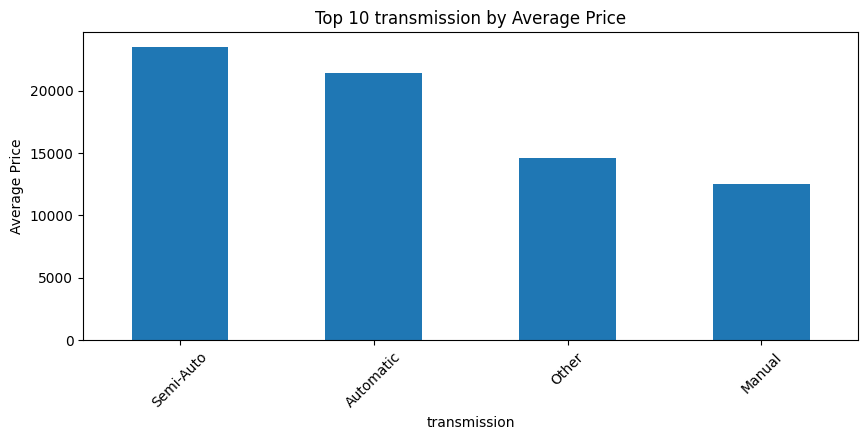

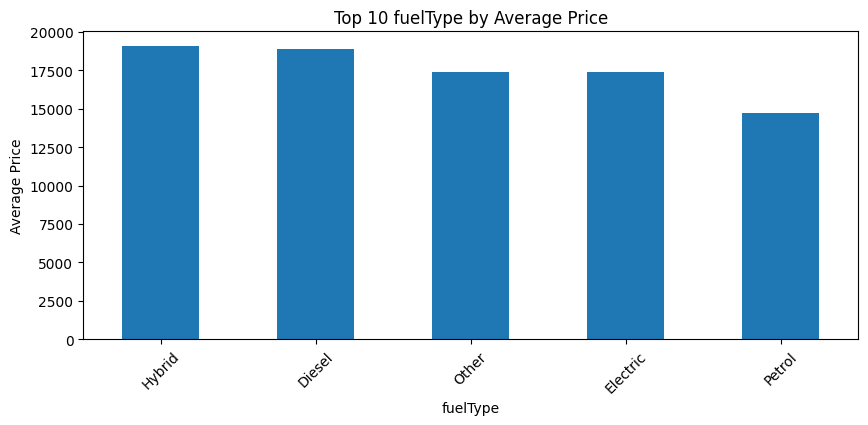

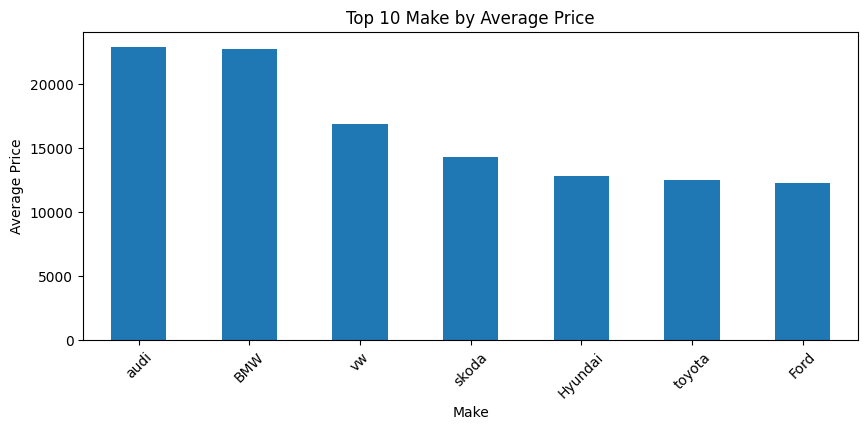

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10,4))

    top10 = df.groupby(col)['price'].mean().sort_values(ascending=False).head(10)

    top10.plot(kind='bar')

    plt.title(f"Top 10 {col} by Average Price")
    plt.xticks(rotation=45)
    plt.ylabel("Average Price")
    plt.show()

In [ ]:
df['Make'] = df['Make'].fillna(method='bfill')

In [ ]:
df.isnull().sum()

,0
model,3621
year,3622
price,3621
transmission,3623
mileage,3622
fuelType,3622
tax,3621
mpg,3621
engineSize,3622
Make,0


In [ ]:
df = df.dropna(subset=['price'])

In [ ]:
df['transmission'].value_counts()

,count
transmission,
Manual,38748
Semi-Auto,13892
Automatic,12711
Other,4


In [ ]:
df = df[~df['transmission'].fillna('').str.strip().str.lower().eq('other')]

In [ ]:
df['transmission'].value_counts()

,count
transmission,
Manual,38748
Semi-Auto,13892
Automatic,12711


In [ ]:
df['fuelType'].value_counts()

,count
fuelType,
Petrol,36481
Diesel,26052
Hybrid,2603
Other,208
Electric,5


In [ ]:
df = df[~df['fuelType'].fillna('').str.strip().str.lower().eq('other')]

In [ ]:
df['fuelType'].value_counts()

,count
fuelType,
Petrol,36481
Diesel,26052
Hybrid,2603
Electric,5


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,X1,2019.0,25890.0,Semi-Auto,5385.0,Petrol,145.0,35.3,2.0,BMW
1,Golf,2019.0,17990.0,Semi-Auto,4459.0,Petrol,145.0,47.1,1.5,vw
2,Tiguan,2017.0,17790.0,Manual,41221.0,Diesel,125.0,NaN,2.0,vw
3,Edge,2018.0,24800.0,Manual,8970.0,Diesel,150.0,47.9,2.0,Ford
4,Fiesta,2019.0,13120.0,Manual,5166.0,Petrol,145.0,58.9,1.0,Ford
5,T-Roc,2018.0,16999.0,Manual,11657.0,Petrol,145.0,55.4,1.0,vw
6,Kuga,2019.0,21450.0,Manual,2723.0,Petrol,145.0,35.3,1.5,Ford
7,Kuga,2019.0,17865.0,Manual,10768.0,Diesel,145.0,38.2,2.0,Ford
8,Kuga,2015.0,9295.0,Manual,88650.0,Diesel,125.0,60.1,2.0,Ford
9,Tucson,2017.0,12998.0,Manual,6318.0,Petrol,160.0,44.8,1.6,Hyundai


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

### Outlier Removal from Target Variable (Price) - Applied In-Place

In [ ]:
# Identify outliers in y_train and y_test
outliers_train_indices = remove_outliers_iqr(y_train.to_frame(), 'price')
outliers_test_indices = remove_outliers_iqr(y_test.to_frame(), 'price')

# remove outliers from training data and update X_train, y_train in place
X_train = X_train.drop(outliers_train_indices)
y_train = y_train.drop(outliers_train_indices)

# remove outliers from testing data and update X_test, y_test in place
X_test = X_test.drop(outliers_test_indices)
y_test = y_test.drop(outliers_test_indices)

print(f"Training samples after outlier removal: {len(y_train)}")
print(f"Test samples after outlier removal: {len(y_test)}")

Training samples after outlier removal: 52567
Test samples after outlier removal: 13088


In [ ]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

In [ ]:
X_train.drop('model', axis=1, inplace=True)
X_test.drop('model', axis=1, inplace=True)

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

In [ ]:
#encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
columns = X_train.columns

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (52567, 16)
Test shape: (13088, 16)


In [ ]:
X_train.head()

,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,-1.459957,2.344736,-1.536929,0.707048,0.848982,0.754150,-0.482473,-0.008723,-0.200113,-1.199993,-0.591359,-0.272798,-0.399916,-0.315141,-0.323461,1.937350
1,-0.972476,0.972322,-1.378192,0.413518,0.848982,-1.325996,-0.482473,-0.008723,-0.200113,-1.199993,-0.591359,-0.272798,-0.399916,-0.315141,-0.323461,1.937350
2,-0.484996,0.232378,0.129813,-0.330090,-0.788023,-1.325996,2.072653,-0.008723,-0.200113,0.833338,-0.591359,-0.272798,-0.399916,3.173179,-0.323461,-0.516169
3,-0.484996,0.469745,-1.854404,1.437610,0.439731,-1.325996,-0.482473,-0.008723,4.997183,-1.199993,-0.591359,-0.272798,-0.399916,-0.315141,3.091560,-0.516169
4,-1.459957,0.065789,-1.378192,0.159126,-1.197274,0.754150,-0.482473,-0.008723,-0.200113,0.833338,-0.591359,-0.272798,-0.399916,-0.315141,3.091560,-0.516169


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2405.564831972548
MSE: 10498664.057209257
RMSE: 3240.164202198595
R2 Score: 0.7724339838635309


### Visualizations After Outlier Removal

#### Residuals Plot (Cleaned Data)

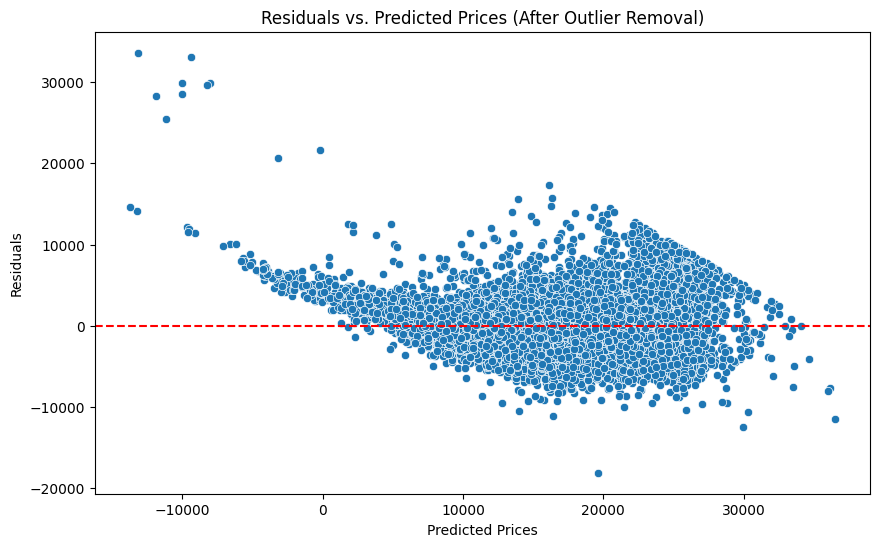

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Prices (After Outlier Removal)')
plt.show()

#### Actual vs. Predicted Prices with Ideal Line (Cleaned Data)

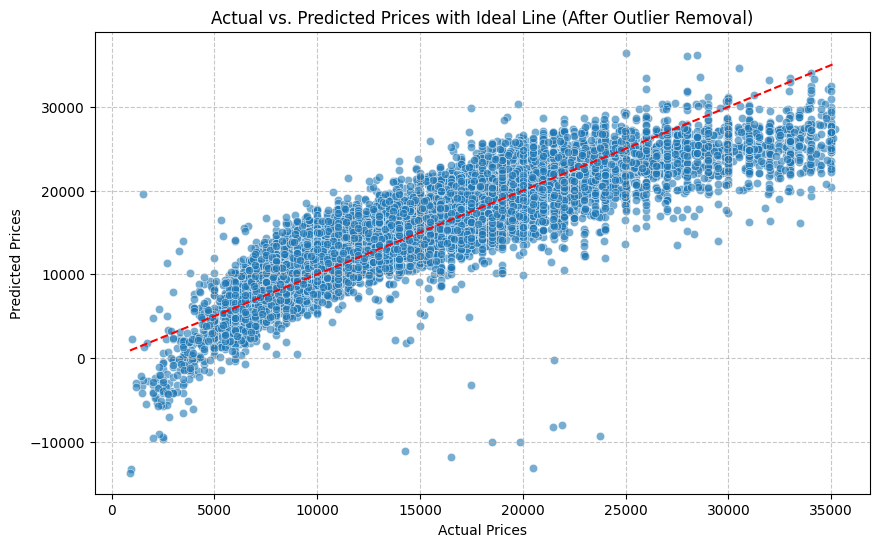

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ideal line y=x
plt.title('Actual vs. Predicted Prices with Ideal Line (After Outlier Removal)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

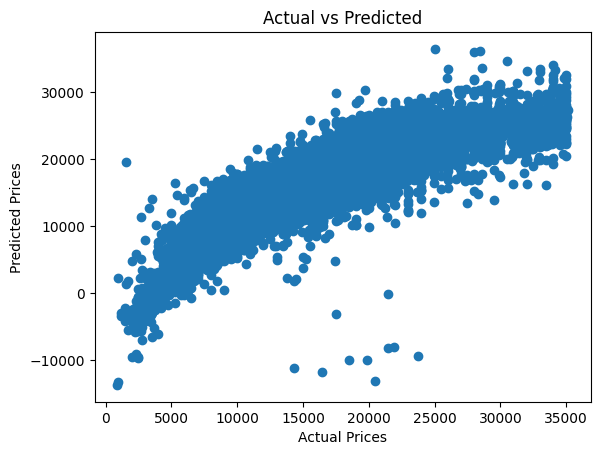

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.7822591260215264
Test R2: 0.7724339838635309


## Visualizations For Regression

### Residuals Plot


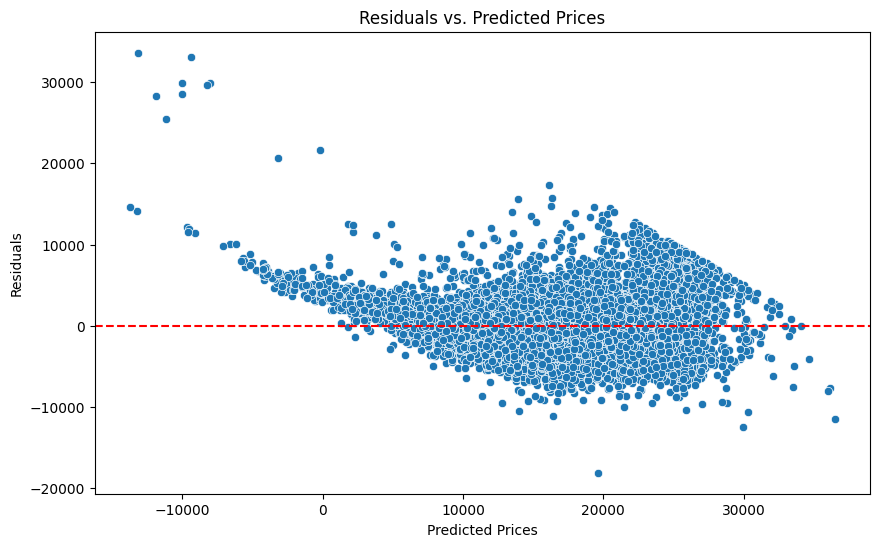

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Prices')
plt.show()

### Feature Importance  (Model Coefficients)


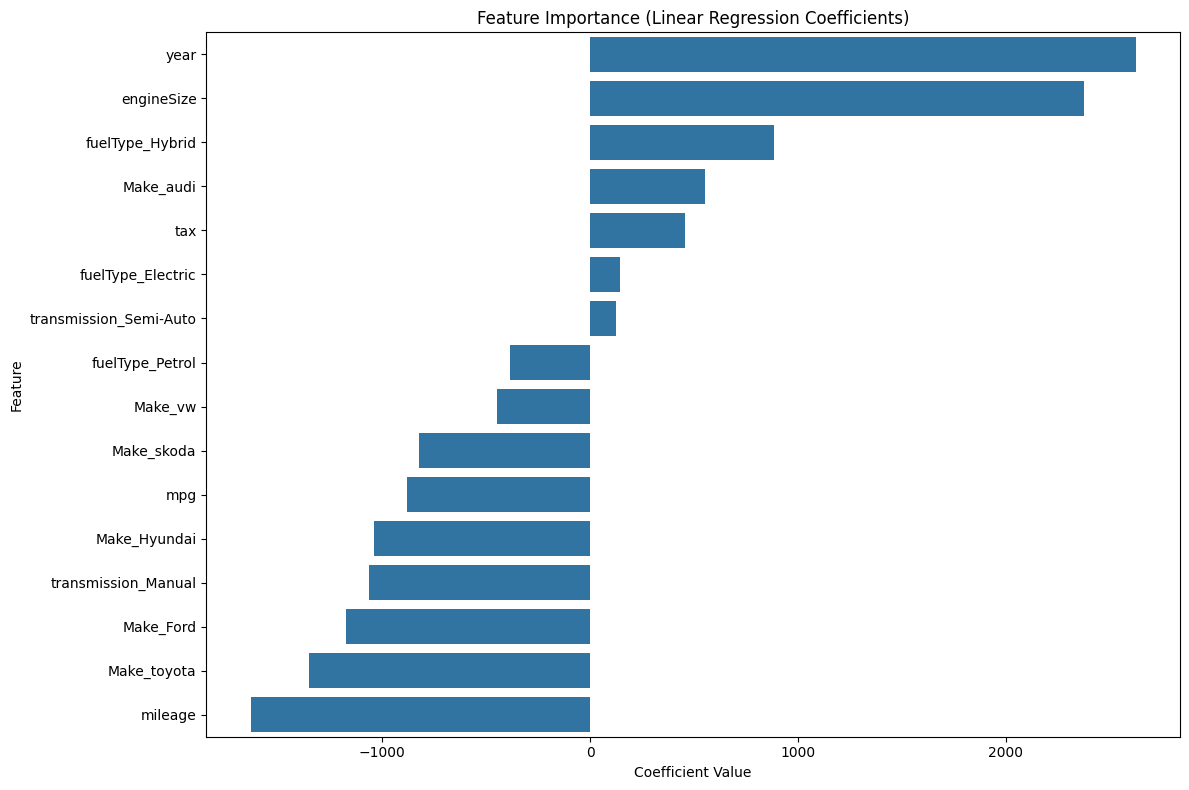

In [ ]:
feature_names = X_train.columns
coefficients = model.coef_

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Histogram of Residuals


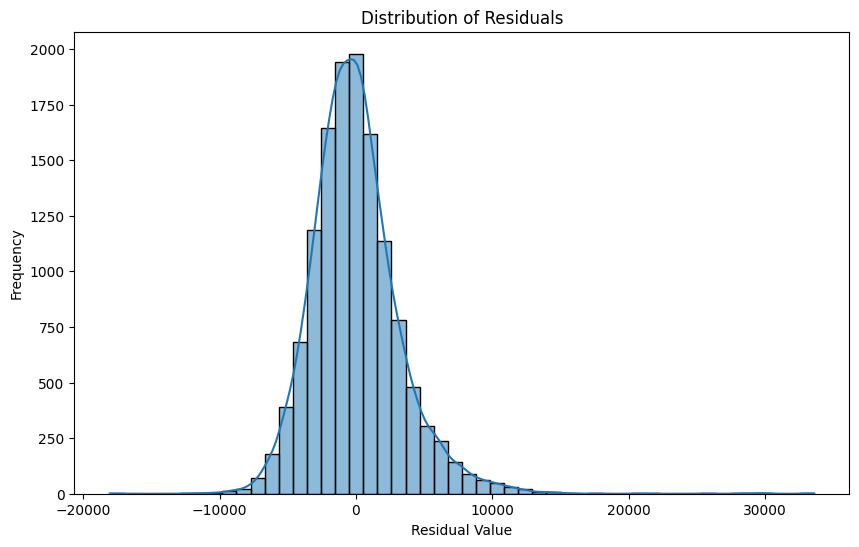

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

### Actual vs. Predicted Prices with Ideal Line


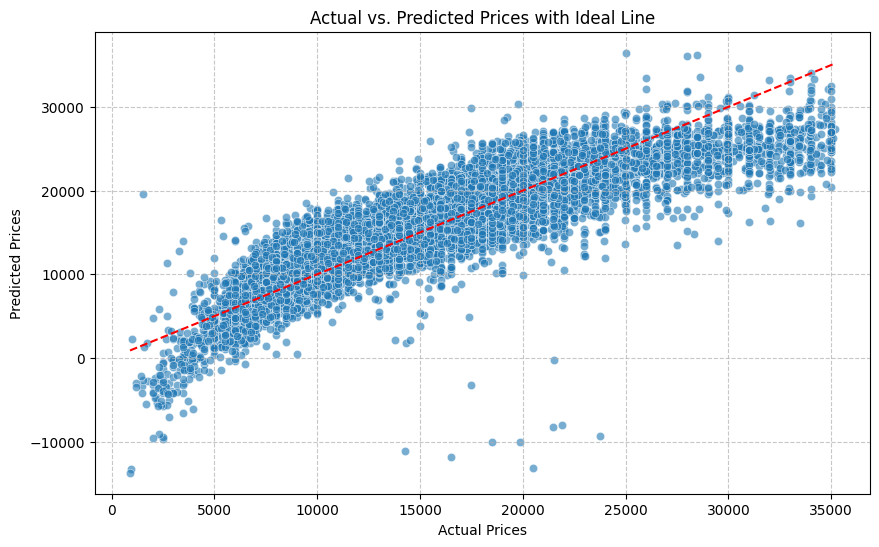

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ideal line y=x
plt.title('Actual vs. Predicted Prices with Ideal Line')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
coefficients = model.coef_

for feature, coef in zip(feature_names, coefficients):
    print(feature, coef)

year 2624.418822069421
mileage -1633.5048839048773
tax 456.0831696344957
mpg -878.5905250507294
engineSize 2376.742250214773
transmission_Manual -1064.111390205347
transmission_Semi-Auto 124.43187219631369
fuelType_Electric 144.83956871386363
fuelType_Hybrid 883.9426085042718
fuelType_Petrol -386.92355302403996
Make_Ford -1174.2923924450893
Make_Hyundai -1040.44735996353
Make_audi 551.7388717494865
Make_skoda -821.2182992407547
Make_toyota -1353.9938349863194
Make_vw -449.93916843359426


#  KNN



# Goals

Train a K-Nearest Neighbors (KNN) classifier to predict the price category.

Use Grid Search, kfold to find the best combination of parameters:
1. Number of neighbours: 3, 5, 7, 9,…….
2. Distance metric: Euclidean, Manhattan

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
train = pd.read_csv('training.csv')
test = pd.read_csv('testing.csv')

In [ ]:
print(train['price'].describe())

print("\nThresholds chosen based on data distribution:")
print("Cheap     : price <= 10,140  (25th percentile)")
print("Moderate  : 10,140 < price <= 20,303  (75th percentile)")
print("Expensive : price > 20,303")

print("\nCars per category in Training set:")
print(y_train.value_counts())

print("\nCars per category in Testing set:")
print(y_test.value_counts())

count    52567.000000
mean     15383.594251
std       6893.551431
min        495.000000
25%       9998.000000
50%      13995.000000
75%      19500.000000
max      35500.000000
Name: price, dtype: float64

Thresholds chosen based on data distribution:
Cheap     : price <= 10,140  (25th percentile)
Moderate  : 10,140 < price <= 20,303  (75th percentile)
Expensive : price > 20,303

Cars per category in Training set:
price
Moderate     25879
Cheap        13625
Expensive    13063
Name: count, dtype: int64

Cars per category in Testing set:
price
Moderate     6547
Cheap        3304
Expensive    3237
Name: count, dtype: int64


In [ ]:
#split X and Y from the data
x_train = train.drop('price',axis=1)
y_train = pd.cut(train['price'],
               bins=[0, 10000, 19500, float('inf')],
               labels=['Cheap', 'Moderate', 'Expensive'])

x_test = test.drop('price',axis=1)
y_test = pd.cut(test['price'],
               bins=[0, 10000, 19500, float('inf')],
               labels=['Cheap', 'Moderate', 'Expensive'])

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': range(3,15,2),
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

In [ ]:
# 7. Grid Search with K-Fold (cv=5) 5 fold cross validation

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52567 entries, 0 to 52566
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    52567 non-null  float64
 1   mileage                 52567 non-null  float64
 2   tax                     52567 non-null  float64
 3   mpg                     52567 non-null  float64
 4   engineSize              52567 non-null  float64
 5   transmission_Manual     52567 non-null  bool   
 6   transmission_Semi-Auto  52567 non-null  bool   
 7   fuelType_Electric       52567 non-null  bool   
 8   fuelType_Hybrid         52567 non-null  bool   
 9   fuelType_Petrol         52567 non-null  bool   
 10  Make_Ford               52567 non-null  bool   
 11  Make_Hyundai            52567 non-null  bool   
 12  Make_audi               52567 non-null  bool   
 13  Make_skoda              52567 non-null  bool   
 14  Make_toyota             52567 non-null

In [ ]:
train.isna().sum()

,0
year,0
mileage,0
tax,0
mpg,0
engineSize,0
transmission_Manual,0
transmission_Semi-Auto,0
fuelType_Electric,0
fuelType_Hybrid,0
fuelType_Petrol,0


In [ ]:
train.isna().sum()

,0
year,0
mileage,0
tax,0
mpg,0
engineSize,0
transmission_Manual,0
transmission_Semi-Auto,0
fuelType_Electric,0
fuelType_Hybrid,0
fuelType_Petrol,0


In [ ]:
#train model
grid.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(3, 15, 2),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
# 9. Best results
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.8642684154862407


In [ ]:
y_pred = grid.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8632334963325183
              precision    recall  f1-score   support

       Cheap       0.88      0.84      0.86      3304
   Expensive       0.87      0.86      0.86      3237
    Moderate       0.85      0.88      0.87      6547

    accuracy                           0.86     13088
   macro avg       0.87      0.86      0.86     13088
weighted avg       0.86      0.86      0.86     13088



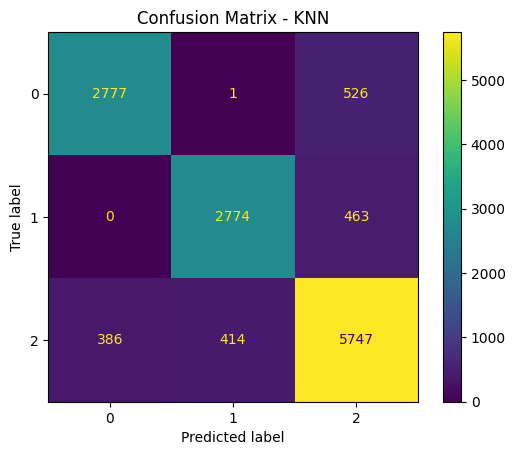

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

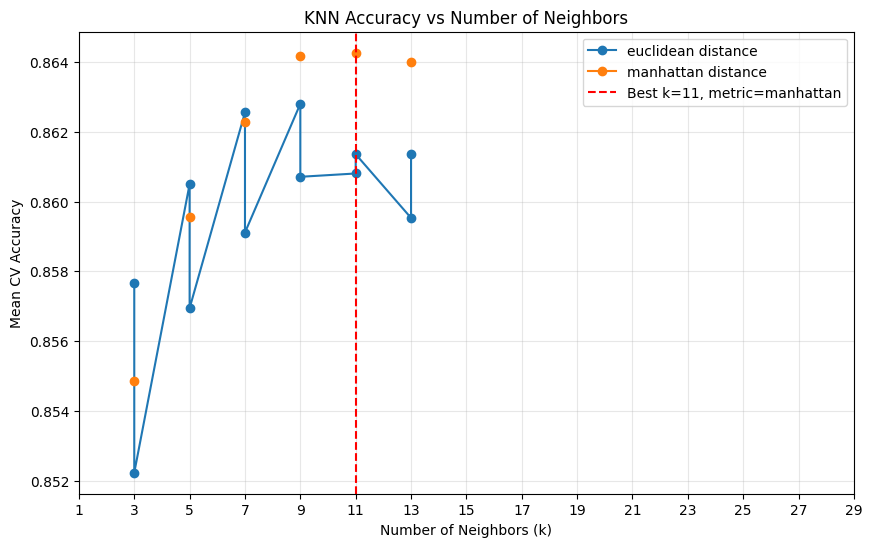

In [ ]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(10,6))

for metric in ['euclidean', 'manhattan']:
    subset = results[results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'],
             subset['mean_test_score'],
             label=f'{metric} distance',
             marker='o')

best_k = grid.best_params_['n_neighbors']
best_metric = grid.best_params_['metric']
plt.axvline(best_k, color='red', linestyle='--',
            label=f'Best k={best_k}, metric={best_metric}')

plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(1, 31, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Try running KNN without scaling — how much does performance change?

In [ ]:
grid_ns = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_ns.fit(x_train, y_train)

y_pred_ns = grid_ns.predict(x_test)
print("Accuracy WITHOUT Scaling:", accuracy_score(y_test, y_pred_ns))
print("Accuracy WITH Scaling:", accuracy_score(y_test, y_pred))

Accuracy WITHOUT Scaling: 0.6309596577017115
Accuracy WITH Scaling: 0.8632334963325183


Accuracy WITHOUT Scaling: 0.64815097799511
Accuracy WITH Scaling: 0.8668245721271394

Try a different threshold for your price categories — does KNN accuracy change
significantly?

In [ ]:
# Different threshold
y_train_t = pd.qcut(train['price'], q=3, labels=['Cheap', 'Moderate', 'Expensive'])
y_test_t = pd.qcut(test['price'], q=3, labels=['Cheap', 'Moderate', 'Expensive'])

x_train_t_scaled = scaler.fit_transform(x_train)
x_test_t_scaled = scaler.transform(x_test)

grid_t = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_t.fit(x_train_t_scaled, y_train_t)

y_pred_t = grid_t.predict(x_test_t_scaled)
print("Accuracy with NEW threshold:", accuracy_score(y_test_t, y_pred_t))
print("Accuracy with OLD threshold:", accuracy_score(y_test, y_pred))

Accuracy with NEW threshold: 0.8543704156479217
Accuracy with OLD threshold: 0.8668245721271394

# Does converting price into categories lose important information?

Yes, converting price into categories loses some information. For example, two cars priced at 8,000 and 12,499 are both labeled as Cheap despite their price difference. However, this is acceptable since our goal is classification, not predicting the exact price.



### Which model performed better?
- **Linear Regression** is evaluated using MAE, RMSE, and R² score. A high R² (close to 1) means the model explains most of the variance in price.
- **KNN Classification** is evaluated using Accuracy, Precision, Recall, and F1-score. Our KNN achieved ~86.7% accuracy after scaling.

"Better" means different things here:
- For Regression → lower RMSE and higher R² is better.
- For Classification → higher accuracy and balanced F1-score is better.

### Is classification easier than regression on this dataset?
Yes, classification is generally easier here because:
- We only need to assign a car to a broad category (Cheap/Moderate/Expensive), not predict an exact number.
- Small prediction errors don't matter as long as the car lands in the right category.
- Regression must predict the exact price, which is harder due to high variance in car prices.